In [1]:
from qiskit.circuit import Parameter, QuantumCircuit, QuantumRegister, ClassicalRegister

from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from scipy.optimize import minimize 
from qiskit.circuit.library import QFT
from qiskit import transpile
from qiskit.circuit.library import UnitaryGate

import random
import matplotlib.pyplot as plt
import scipy.linalg as scl
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

service = QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=your_api_key,
    instance=your_crn,
    name="INSTANCE NAME",
    overwrite=True
)
# We define a specific backend
backend = service.backend("ibm_fez")
pm = generate_preset_pass_manager(backend = backend, optimization_level = 2)

In [2]:


I = np.array([[1,0],[0,1]])
X = np.array([[0,1],[1,0]])
Y = np.array([[0,-1j],[1j,0]])
Z = np.array([[1,0],[0,-1]])

m = np.array([[1, 0, 0, 0],
                 [0, 2, -1, 0],
                 [0, -1, 2, -1],
                 [0, 0, -1, 2]])
b = np.array([0,np.sqrt(2)/2,0.5,0.5])
nb_qubits = 2

def U_b(nb_qubits):
    circ = QuantumCircuit(nb_qubits)
    circ.prepare_state(b)
    return circ
U = U_b(nb_qubits)
b = np.array(Statevector(U_b(nb_qubits)))

def Hamiltonian(m):
    Ub = np.array(Operator(U_b(nb_qubits)))
    z = np.array([[1,0],
                 [0,-1]])
    I = np.array([[1,0],
                 [0,1]])
    def tensor(k,l):
        return np.kron(k,l)
    M1 = (np.dot(np.dot(Ub,tensor(z,I)),np.conj(Ub.T))
        + np.dot(np.dot(Ub,tensor(I,z)),np.conj(Ub.T)))
    M = 0.5*np.dot(np.dot(np.conj(m.T),(tensor(I,I) - M1/nb_qubits)),m)

    return M
A = Hamiltonian(m)

x_exact = np.linalg.solve(m,b)
x_exact = x_exact/np.linalg.norm(x_exact)
U1=scl.expm(2**0*2*np.pi*1j*A) 
U2=scl.expm(2**1*2*np.pi*1j*A) 
U3=scl.expm(2**2*2*np.pi*1j*A) 
U4=scl.expm(2**3*2*np.pi*1j*A) 

 
u1gate = UnitaryGate(U1)
u2gate = UnitaryGate(U2)
u3gate=UnitaryGate(U3)
u4gate=UnitaryGate(U4)


C_u1gate=u1gate.control()
C_u2gate=u2gate.control()
C_u3gate=u3gate.control()
C_u4gate=u4gate.control()
    

In [3]:
RMSE = []
nb_qubits = 2
depth = 2
qubits = list(range(nb_qubits))
N = len(qubits)
nb_params = int(9*N*depth)
RMSE = []
rep = 10
# for _ in range(rep):
parameters = np.array([random.random() for _ in range(0, nb_params)])
def ansatz(parameters):
    qc = QuantumCircuit(N)
    for d in range(depth):
        param1=parameters[d*9*N:(d+1)*(9*N)]
        for q in range(N):
            qc.ry(param1[q],qubits[q])
            qc.ry(param1[q+N],qubits[q])
            qc.ry(param1[q+2*N],qubits[q])
        qc.barrier()
        for q in range(N):
            qc.cx(qubits[q], qubits[(q+1)% N])
            qc.ry(param1[q+3*N],qubits[q])
            qc.ry(param1[q+4*N],qubits[(q+1)% N])
            qc.cx(qubits[(q+1)% N], qubits[q])
            qc.ry(param1[q+5*N],qubits[(q+1)% N])
            qc.cx(qubits[q], qubits[(q+1)% N])
        qc.barrier()
        if d==depth-1:
            for q in range(N):
                qc.ry(param1[q+6*N],qubits[q])
                qc.ry(param1[q+7*N],qubits[q])
                qc.ry(param1[q+8*N],qubits[q])
        qc.barrier()
    
    return qc  
parameters = np.array([0.44695365, 0.39270149, 0.15749515, 0.30193322, 0.27449887, 0.11393758,
 0.76124325, 0.89809937, 0.30752423, 0.55637787, 0.14572185, 0.26398618,
 0.90643772, 0.51891575, 0.14491294, 0.55367484, 0.5784063 , 0.20420283,
 0.76220681, 0.86232149 ,0.80590347, 0.66226839, 0.95141653, 0.21462997,
 0.36056842 ,0.26912613, 0.32501986, 0.72494903 ,0.84831313, 0.63225765,
 0.06182932 ,0.14785665, 0.53865705 ,0.40237743 ,0.90567154, 0.8519512 ])

In [4]:
def circ(parameters):
    x=QuantumRegister(6)
    c=ClassicalRegister(4)
    circuit = QuantumCircuit(x,c)
    phi=parameters
    circuit=circuit.compose(ansatz(parameters),x[4:6])
    circuit.h(x[0:4])

#Apply the C-U operations where the controlled qubits are the qubits of the register x and the target from y    
    circuit.append(C_u1gate, [x[0],x[4],x[5]])    
    circuit.append(C_u2gate, [x[1],x[4],x[5]])    
    circuit.append(C_u3gate, [x[2],x[4],x[5]])    
    circuit.append(C_u4gate, [x[3],x[4],x[5]])    

#Apply the inverse QFT on the x register   
    circuit &= QFT(num_qubits = 4, approximation_degree = 0, do_swaps = True, 
                   inverse = True, insert_barriers = False, name = 'qft')
    circuit.measure(x[0:4],c)       
    return circuit
 

In [5]:
import mthree   
shots = 100000
def cost(parameters):
    qct = pm.run(circ(parameters))
    job = backend.run(qct, shots = shots).result()
    result = job.get_counts(0)
    res = 1 - result['0000']/shots
    return res
# cost(parameters)

In [6]:
def Optimizer(fun, x0, args=(), maxfev=None, 
              reset_interval=None, eps=None, callback=None, **_):
    
    x0 = np.asarray(x0)
    recycle_z0 = None
    niter = 0
    funcalls = 0

    while True:

        idx = niter % x0.size

        if reset_interval > 0:
            if niter % reset_interval == 0:
                recycle_z0 = None

        if recycle_z0 is None:
            z0 = fun(np.copy(x0), *args)
            funcalls += 1
        else:
            z0 = recycle_z0
    
        p = np.copy(x0)
        p[idx] = x0[idx] + np.pi / 2
        z1 = fun(p, *args)
        funcalls += 1

        p = np.copy(x0)
        p[idx] = x0[idx] - np.pi / 2
        z3 = fun(p, *args)
        funcalls += 1

        z2 = z1 + z3 - z0
        c = (z1 + z3) / 2
        a = np.sqrt((z0 - z2) ** 2 + (z1 - z3) ** 2) / 2
        b = np.arctan((z1 - z3) / ((z0 - z2) + 1e-32 * (z0 == z2))) + x0[idx]
        b += 0.5 * np.pi + 0.5 * np.pi * np.sign((z0 - z2) + eps * (z0 == z2))
        x0[idx] = b
        recycle_z0 = c - a
        if callback is not None:
            callback(np.copy(x0))
        if funcalls >= maxfev:
            break
        niter += 1
    # return OptimizeResult(fun=problabel0(np.copy(x0)), x=x0, nit=niter, 
    #                       nfev=funcalls, success=(niter > 1))

In [7]:
def save(parameters):
    global Cost,Params
    Cost.append(cost(parameters))
    Params.append(parameters)
    print(cost(parameters))
Cost = []
Params = []
Optimizer(cost, parameters, args = (), maxfev = 2000, 
          reset_interval = 32, eps = 1e-32, callback=save)

/tmp/ipykernel_908834/3380613089.py:18: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 4, approximation_degree = 0, do_swaps = True,
/tmp/ipykernel_908834/3380613089.py:18: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 4, approximation_degree = 0, do_swaps = True,


0.74996
0.70547
0.66187
0.58154
0.53111
0.51196
0.33536
0.33404
0.32823
0.32709
0.35275999999999996
0.32404
0.41283000000000003
0.32149000000000005
0.32320000000000004
0.32103000000000004
0.32011999999999996
0.32175
0.31562999999999997
0.31287
0.31508
0.31311999999999995
0.39698
0.31423
0.34058
0.31374
0.31605000000000005
0.31510000000000005
0.3127
0.31340999999999997
0.31348
0.31572999999999996
0.31492
0.4054
0.31213
0.31531
0.31791
0.31405000000000005
0.31506
0.40476999999999996
0.31466000000000005
0.31296
0.31242000000000003
0.31498000000000004
0.31238999999999995
0.31599999999999995
0.31614
0.31379
0.31335999999999997
0.31383000000000005
0.31455
0.31089
0.3143
0.31435
0.33599
0.33579000000000003
0.31381000000000003
0.31157
0.31579999999999997
0.38852
0.40535
0.3166
0.31237000000000004
0.31591
0.31401
0.33752000000000004
0.31408
0.31133
0.31259000000000003
0.31620000000000004
0.31469
0.31284999999999996
0.31272999999999995
0.31759000000000004
0.31597
0.3385
0.39391
0.314189999999999

In [9]:
e = []
F = []
norm_e = []
for k in range(len(Params)):
    state = np.array(Statevector(ansatz(Params[k])))
    norm = np.dot(state,x_exact)
    e.append(x_exact - state/norm)
    f = abs(np.dot(state,x_exact))**2
    F.append(f)

for v in e:
    norm_e.append(float(np.linalg.norm(v)))
Res = norm_e[np.argmax(F)]
print(Res)
# RMSE.append(Res)

0.000690553243941403


In [10]:
F

[0.3170744888182806,
 0.3911986730334809,
 0.435088342459236,
 0.5755251309234322,
 0.6441841049364544,
 0.688461231418668,
 0.9698478991626415,
 0.9700305938485273,
 0.975218519235218,
 0.9752183606384821,
 0.9759239305208213,
 0.9890180623793136,
 0.9890180623793136,
 0.9890180623793136,
 0.9890180623793136,
 0.9890180623793136,
 0.9890180623793136,
 0.9890180623793136,
 0.9985740125301357,
 0.9986666572116251,
 0.9985858293782064,
 0.9985397874616432,
 0.9985926436979882,
 0.9985807334578953,
 0.9996717313825654,
 0.9996912862749873,
 0.9999835658060131,
 0.9999916376628419,
 0.9999663116458748,
 0.9999994827547873,
 0.9992206363220008,
 0.999654712954297,
 0.9997791605505373,
 0.9998221544661915,
 0.9999065387049039,
 0.9997961383707373,
 0.99965595011134,
 0.9996667836001012,
 0.9998375552687387,
 0.999835895861265,
 0.999953410571689,
 0.9999422176148915,
 0.9999767194355956,
 0.9998738707656137,
 0.9991013389316146,
 0.9994203578159967,
 0.9998103628497748,
 0.9998802101195859,


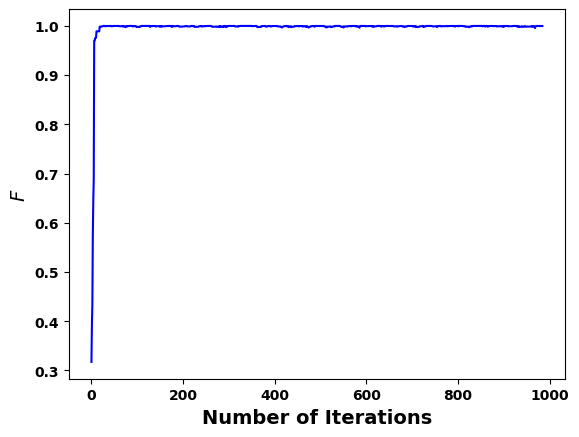

In [11]:
ax = plt.subplot(111)
ax.plot(range(len(F)), F, color = 'b')   

# plt.axis([0, 100, 0, 0.0007])
plt.xlabel('Number of Iterations',fontsize=14,weight='bold')
plt.ylabel('$F$',fontsize=14,weight='bold')
# plt.title('Cost Function for a full random matrix',fontsize=14,weight='bold')

ax = plt.gca()
for tick in ax.get_xticklabels():
	tick.set_fontweight('bold')
for tick in ax.get_yticklabels():
	tick.set_fontweight('bold')
# plt.savefig('cost_full_mat.eps')


In [12]:
norm_e

[1.4675943047139692,
 1.2474958475703601,
 1.139466456232521,
 0.8588035784255597,
 0.7432033700004266,
 0.6726920649738694,
 0.1763221909729827,
 0.17577064761092112,
 0.15940893365891542,
 0.15940945671356913,
 0.1570669499208678,
 0.1053749483287528,
 0.1053749483287528,
 0.1053749483287528,
 0.1053749483287528,
 0.1053749483287528,
 0.1053749483287528,
 0.1053749483287528,
 0.037789202345772696,
 0.036539334489728355,
 0.037632078503796414,
 0.038240657382722254,
 0.03754117399848391,
 0.037699916744458765,
 0.01812115926496681,
 0.0175729638538309,
 0.00405394426139679,
 0.0028917826833679,
 0.005804264731124558,
 0.0007191978037518583,
 0.027927970916330747,
 0.018585109900895687,
 0.014862309050028461,
 0.013337059963472389,
 0.00966799001484053,
 0.01427946768271185,
 0.0185517734927249,
 0.018257258010947106,
 0.012746416117489206,
 0.012811365006249454,
 0.006825803907775059,
 0.007601692186977972,
 0.0048250498859372356,
 0.01123143557059785,
 0.02999115513789153,
 0.0240827

In [15]:
opt_params = Params[np.argmax(F)]
opt_params

array([ 0.3127525 ,  1.1166403 , -0.76892744,  1.26829859, -0.39925471,
        0.57088609,  1.92272618,  1.10854456,  0.39099319,  0.63856995,
        0.13531254,  0.20131732, 15.5161786 ,  2.84288473,  0.3762325 ,
        1.46962829,  0.15018002, -0.75406342,  0.52108299,  0.83990981,
        0.66152569,  0.82315135,  0.84105906,  0.1718751 ,  0.33001823,
        0.25343037,  0.18867166,  0.66953558,  0.88469365,  0.66666424,
        0.22483534,  0.08380557,  0.53777522,  0.40620075,  0.94917914,
        0.90269738])

In [4]:
X_opt = np.array(Statevector(ansatz(opt_params)))
X_opt = np.array([-0.00067473+0.j, -0.55298928+0.j, -0.6741502 +0.j, -0.48961608+0.j])

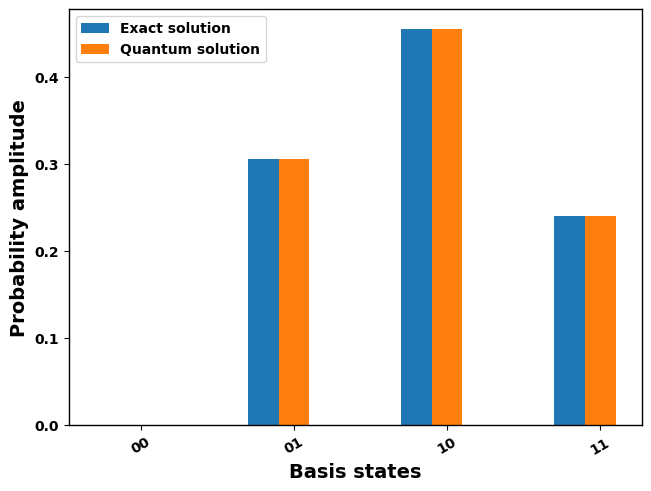

In [10]:
states = ('00', '01','10','11')
Solutions = {
    'Exact solution': np.round(abs(x_exact)**2,6),
    'Quantum solution': np.round(abs(X_opt)**2,6),
}

x = np.arange(len(states))  # the label locations
width = 0.2  # the width of the bars
multiplier = 0

fig, ax3 = plt.subplots(layout = 'constrained')

plt.rc('axes', linewidth = 1)
legend_properties = {'weight':'bold'}

for attribute, measurement in Solutions.items():
    offset = width * multiplier
    rects = ax3.bar(x + offset, measurement, width, label = attribute)
    # ax3.bar_label(rects, padding=2)
    multiplier += 1

plt.xlabel('Basis states',fontsize = 14,weight='bold')
plt.ylabel('Probability amplitude',fontsize=14,weight='bold')

legend = plt.legend(fontsize = 20,prop = legend_properties)

ax3.set_xticks(x + width, states,rotation = 30)
# ax3.legend(loc='upper left', ncols = 2)

ax3 = plt.gca()
for tick in ax3.get_xticklabels():
	tick.set_fontweight('bold')
for tick in ax3.get_yticklabels():
	tick.set_fontweight('bold')
plt.savefig('fig8a.pdf')
